# Обедающие философы: итоговый отчёт

Сравним две сети по одному показателю --- числу философов, которые
едят. Скрипт не запускает моделирование, а загружает файлы, которые
сохранил скрипт `dining_philosophers.jl`.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
using DataFrames, CSV, Plots

## Загрузка данных

In [2]:
df_classic = CSV.read(datadir("dining_classic.csv"), DataFrame)
df_arbiter = CSV.read(datadir("dining_arbiter.csv"), DataFrame)
N = 5

5

Столбцы для состояния «Ест»:

In [3]:
eat_cols = [Symbol("Eat_$i") for i = 1:N]
labels = permutedims(["Ф $i" for i = 1:N])

1×5 Matrix{String}:
 "Ф 1"  "Ф 2"  "Ф 3"  "Ф 4"  "Ф 5"

## Построение графиков

Состояние меняется скачком в момент события, поэтому линии
ступенчатые.

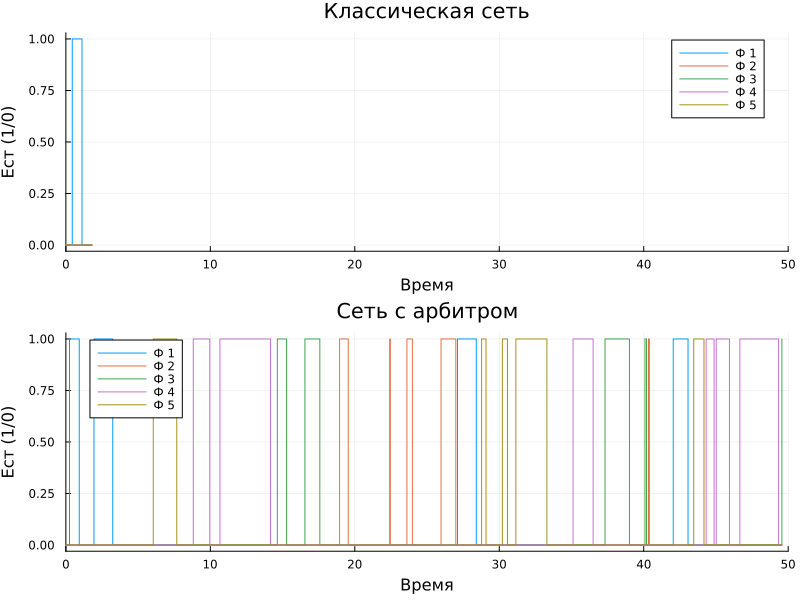

In [4]:
p1 = plot(
    df_classic.time,
    Matrix(df_classic[:, eat_cols]),
    label = labels,
    seriestype = :steppost,
    xlabel = "Время",
    ylabel = "Ест (1/0)",
    title = "Классическая сеть",
    xlims = (0, 50),
)
p2 = plot(
    df_arbiter.time,
    Matrix(df_arbiter[:, eat_cols]),
    label = labels,
    seriestype = :steppost,
    xlabel = "Время",
    ylabel = "Ест (1/0)",
    title = "Сеть с арбитром",
    xlims = (0, 50),
)
p_final = plot(p1, p2, layout = (2, 1), size = (800, 600))

## Сохранение графика

In [5]:
savefig(p_final, plotsdir("final_report.png"))
println("Отчёт сохранён в plots/final_report.png")

Отчёт сохранён в plots/final_report.png
